# Global Determinants of Life Expectancy (2002–2022)
### A Multivariate ELT Data Pipeline & Exploratory Analysis

**Author:** Viet Thang Tran | **Module:** Data Operations & Management | **Institution:** Atlantic Technological University

---

## Overview

This notebook implements a complete **Extract → Load → Transform (ELT)** pipeline to investigate the global determinants of life expectancy across 180+ countries from 2002 to 2022.

Seven datasets are sourced from [Our World in Data](https://ourworldindata.org), merged into a unified analytical dataframe, cleaned, validated, and exported for downstream visualisation in Tableau.

### Research Questions
1. How has global life expectancy changed from 2002 to 2022?
2. Which socio-economic, healthcare, and environmental factors are most strongly associated with life expectancy?
3. What actionable insights can inform public health policy?

### Pipeline Structure
```
┌─────────┐    ┌──────┐    ┌────────────┐    ┌──────────────┐      ┌──────────┐
│ Extract │───▶│ Load │───▶│  Merge &   │───▶│  Validate &  │───▶│  Export  │
│  (OWID) │    │  (df)│    │ Preprocess │    │     EDA      │      │  (.xlsx) │
└─────────┘    └──────┘    └────────────┘    └──────────────┘      └──────────┘
```

### Datasets Used
| Dataset | Variable | Source |
|---|---|---|
| Life Expectancy at Birth | `Average Life Expectancy` | UN World Population Prospects |
| Vaccination Coverage | `DTP3 / MCV1 / POL3 %` | WHO / UNICEF (WUENIC) |
| GDP per Capita | `GDP per capita` | World Bank (constant USD) |
| Healthcare Expenditure | `Total Health Spending` | WHO Global Health Expenditure DB |
| Diet Composition | `Animal Protein / Plant Protein / Fat / Carbohydrates` | FAO Food Balance Sheets |
| CO₂ Emissions | `Total Emissions` | Global Carbon Project |
| Child Mortality Rate | `Child Mortality Rate` | Gapminder / UN IGME |

---
## Section 1 — Environment Setup

Install and import all required libraries. We use `pandas` for data manipulation, `matplotlib` and `seaborn` for in-notebook exploratory visualisation, and `warnings` to suppress non-critical output.

In [1]:
# Install dependencies (only needed if running in a fresh environment)
!pip install pandas numpy matplotlib seaborn openpyxl --quiet

In [2]:
import warnings
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')

os.makedirs('../data', exist_ok=True)

# Global plot styling
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print(f"pandas  {pd.__version__}")
print(f"numpy   {np.__version__}")
print("Environment ready ✓")

pandas  3.0.2
numpy   2.4.4
Environment ready ✓


---
## Section 2 — Extract & Load

Each dataset is fetched directly from the Our World in Data API in CSV format. A `load_owid` helper function centralises error handling and prints a brief shape/column summary for each dataset on load — making the pipeline easy to debug and extend.

In [3]:
OWID_HEADERS = {'User-Agent': 'Our World In Data data fetch/1.0'}

SOURCES = {
    'life_expectancy':   'https://ourworldindata.org/grapher/life-expectancy.csv?v=1&csvType=full&useColumnShortNames=true',
    'vaccination':       'https://ourworldindata.org/grapher/vaccination-coverage-who-unicef.csv?v=1&csvType=full&useColumnShortNames=true&metric=coverage&antigen=comparison',
    'gdp':               'https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.csv?v=1&csvType=full&useColumnShortNames=true',
    'health_spending':   'https://ourworldindata.org/grapher/annual-healthcare-expenditure-per-capita.csv?v=1&csvType=full&useColumnShortNames=true',
    'diet':              'https://ourworldindata.org/grapher/daily-caloric-supply-derived-from-carbohydrates-protein-and-fat.csv?v=1&csvType=full&useColumnShortNames=true',
    'co2_emissions':     'https://ourworldindata.org/grapher/annual-co2-emissions-per-country.csv?v=1&csvType=full&useColumnShortNames=true',
    'child_mortality':   'https://ourworldindata.org/grapher/child-mortality.csv?v=1&csvType=full&useColumnShortNames=true',
}

def load_owid(name: str, url: str) -> pd.DataFrame:
    """Fetch an OWID CSV dataset and print a brief audit summary."""
    df = pd.read_csv(url, storage_options=OWID_HEADERS)
    print(f"[{name}]  rows={len(df):,}  cols={df.shape[1]}  years={df['year'].min()}–{df['year'].max()}")
    return df

# --- Extract & Load all datasets ---
print("Extracting datasets from Our World in Data...\n")
df_le  = load_owid('life_expectancy', SOURCES['life_expectancy'])
df_cv  = load_owid('vaccination',     SOURCES['vaccination'])
df_gdp = load_owid('gdp',             SOURCES['gdp'])
df_hs  = load_owid('health_spending', SOURCES['health_spending'])
df_dc  = load_owid('diet',            SOURCES['diet'])
df_co2 = load_owid('co2_emissions',   SOURCES['co2_emissions'])
df_cm  = load_owid('child_mortality', SOURCES['child_mortality'])
print("\nAll datasets loaded successfully ✓")

Extracting datasets from Our World in Data...

[life_expectancy]  rows=21,565  cols=4  years=1543–2023
[vaccination]  rows=9,203  cols=12  years=1980–2024
[gdp]  rows=12,164  cols=4  years=1960–2024
[health_spending]  rows=4,869  cols=4  years=2000–2024
[diet]  rows=13,032  cols=7  years=1961–2023
[co2_emissions]  rows=29,384  cols=4  years=1750–2024
[child_mortality]  rows=16,835  cols=4  years=1751–2023

All datasets loaded successfully ✓


---
## Section 3 — Merge

All datasets are joined sequentially using `inner` merges on the composite key `['Entity', 'Code', 'Year']`. An inner join ensures only country-year combinations present across **all** datasets are retained, guaranteeing a complete-case analytical dataframe with no missing values introduced by the join itself.

> **Design note:** The merge order is chosen to maximise retention — life expectancy and vaccination data share the broadest country coverage, so they form the base.

In [4]:
JOIN_KEYS = ['entity', 'code', 'year']

merge_steps = [
    ('vaccination',     df_cv),
    ('gdp',             df_gdp),
    ('health_spending', df_hs),
    ('diet',            df_dc),
    ('co2_emissions',   df_co2),
    ('child_mortality', df_cm),
]

df = df_le.copy()
print(f"Base (life expectancy):  {len(df):,} rows")

for name, frame in merge_steps:
    before = len(df)
    df = df.merge(frame, on=JOIN_KEYS, how='inner')
    print(f"After merging {name:<18}: {len(df):,} rows  (lost {before - len(df):,})")

print(f"\nFinal merged shape: {df.shape}")

Base (life expectancy):  21,565 rows
After merging vaccination       : 8,375 rows  (lost 13,190)
After merging gdp               : 7,886 rows  (lost 489)
After merging health_spending   : 4,581 rows  (lost 3,305)
After merging diet              : 4,133 rows  (lost 448)
After merging co2_emissions     : 4,037 rows  (lost 96)
After merging child_mortality   : 4,037 rows  (lost 0)

Final merged shape: (4037, 21)


---
## Section 4 — Transform & Clean

### 4.1 Drop Low-Coverage Vaccine Columns

Several vaccine antigens (HepB3, Hib3, IPV1, PCV3, RCV1, RotaC) have high rates of missingness relative to the core DTP3, MCV1, and POL3 metrics. These are dropped to preserve analytical integrity and avoid over-constraining the inner join.

In [5]:
LOW_COVERAGE_VACCINES = [
    'coverage__antigen_hepb3',
    'coverage__antigen_hib3',
    'coverage__antigen_ipv1',
    'coverage__antigen_pcv3',
    'coverage__antigen_rcv1',
    'coverage__antigen_rotac',
]

# Only drop columns that actually exist (defensive coding)
to_drop = [c for c in LOW_COVERAGE_VACCINES if c in df.columns]
df.drop(columns=to_drop, inplace=True)
print(f"Dropped {len(to_drop)} low-coverage vaccine columns.")
print(f"Remaining columns ({df.shape[1]}): {list(df.columns)}")

Dropped 6 low-coverage vaccine columns.
Remaining columns (15): ['entity', 'code', 'year', 'life_expectancy_0', 'coverage__antigen_mcv1', 'coverage__antigen_dtpcv3', 'coverage__antigen_pol3', 'ny_gdp_pcap_kd', 'sh_xpd_chex_pp_cd', 'energy_from_animal_protein', 'energy_from_vegetal_protein', 'total_energy_from_fat', 'total_energy_from_carbohydrates', 'emissions_total', 'child_mortality_rate']


### 4.2 Rename Columns for Readability

In [6]:
COLUMN_MAP = {
    'entity':                       'Country',
    'life_expectancy_0':            'Average Life Expectancy',
    'coverage__antigen_dtpcv3':     'DTP3 Vaccination Rate (%)',
    'coverage__antigen_mcv1':       'MCV1 Vaccination Rate (%)',
    'coverage__antigen_pol3':       'POL3 Vaccination Rate (%)',
    'ny_gdp_pcap_kd':               'GDP per Capita (USD)',
    'sh_xpd_chex_pp_cd':            'Health Spending per Capita (USD)',
    'energy_from_animal_protein':   'Calories from Animal Protein',
    'energy_from_vegetal_protein':  'Calories from Plant Protein',
    'total_energy_from_fat':        'Calories from Fat',
    'total_energy_from_carbohydrates': 'Calories from Carbohydrates',
    'emissions_total':              'Total CO2 Emissions',
    'child_mortality_rate':         'Child Mortality Rate',
}

df.rename(columns=COLUMN_MAP, inplace=True)
print("Columns renamed:")
df.dtypes

Columns renamed:


Country                                 str
code                                    str
year                                  int64
Average Life Expectancy             float64
MCV1 Vaccination Rate (%)           float64
DTP3 Vaccination Rate (%)           float64
POL3 Vaccination Rate (%)           float64
GDP per Capita (USD)                float64
Health Spending per Capita (USD)    float64
Calories from Animal Protein        float64
Calories from Plant Protein         float64
Calories from Fat                   float64
Calories from Carbohydrates         float64
Total CO2 Emissions                 float64
Child Mortality Rate                float64
dtype: object

### 4.3 Filter Time Range (2002–2022)

A standardised 20-year window is applied to ensure comparability across all datasets, as coverage varies significantly before 2002.

In [7]:
START_YEAR, END_YEAR = 2002, 2022

before = len(df)
df = df[(df['year'] >= START_YEAR) & (df['year'] <= END_YEAR)].copy()
print(f"Filtered to {START_YEAR}–{END_YEAR}: {before:,} → {len(df):,} rows")

Filtered to 2002–2022: 4,037 → 3,554 rows


### 4.4 Remove Countries with Insufficient Temporal Coverage

Countries with fewer than 8 years of observations within the 2002–2022 window are excluded. This threshold balances data completeness with country retention — small island states and newly independent territories typically fall below it.

In [8]:
MIN_YEARS = 8

year_counts = df['Country'].value_counts()
ineligible  = year_counts[year_counts < MIN_YEARS].index.tolist()
eligible    = year_counts[year_counts >= MIN_YEARS].index

print(f"Countries removed (< {MIN_YEARS} years of data): {ineligible}\n")

df = df[df['Country'].isin(eligible)].copy()
print(f"Countries retained: {df['Country'].nunique()}")
print(f"Rows retained:      {len(df):,}")

Countries removed (< 8 years of data): ['Bahrain', 'Bhutan', 'Marshall Islands', 'Micronesia (country)', 'Nauru', 'Qatar', 'Tonga', 'Tuvalu', 'Venezuela']

Countries retained: 174
Rows retained:      3,518


### 4.5 Remove Non-Country Aggregate Entities

Our World in Data includes regional and income-group aggregates (e.g. 'World', 'High-income countries'). These are excluded to prevent double-counting in country-level analyses.

In [9]:
NON_COUNTRIES = [
    'World',
    'High-income countries',
    'Upper-middle-income countries',
    'Lower-middle-income countries',
    'Low-income countries',
]

before = df['Country'].nunique()
df = df[~df['Country'].isin(NON_COUNTRIES)].copy()
print(f"Removed {before - df['Country'].nunique()} aggregate entities.")
print(f"Final country count: {df['Country'].nunique()}")

Removed 1 aggregate entities.
Final country count: 173


### 4.6 Missing Value Audit

A final check confirms no residual missing values exist in the analytical dataframe. The inner merge strategy ensures this by construction, but an explicit audit is good practice before export.

In [10]:
null_summary = df.isnull().sum()

if null_summary.sum() == 0:
    print("No missing values detected. Dataset is complete.")
else:
    print("Missing values found:")
    print(null_summary[null_summary > 0])

No missing values detected. Dataset is complete.


---
## Section 5 — Descriptive Statistics

Summary statistics provide a baseline understanding of the analytical dataset before visualisation. Key indicators are examined for range, central tendency, and spread.

In [11]:
print(f"=== Final Dataset Summary ===")
print(f"Countries : {df['Country'].nunique()}")
print(f"Year range: {df['year'].min()} – {df['year'].max()}")
print(f"Total rows: {len(df):,}")
print()

KEY_COLS = [
    'Average Life Expectancy',
    'GDP per Capita (USD)',
    'Health Spending per Capita (USD)',
    'DTP3 Vaccination Rate (%)',
    'Child Mortality Rate',
    'Total CO2 Emissions',
]

existing_key_cols = [c for c in KEY_COLS if c in df.columns]
df[existing_key_cols].describe().round(2)

=== Final Dataset Summary ===
Countries : 173
Year range: 2002 – 2022
Total rows: 3,497



,Average Life Expectancy,GDP per Capita (USD),Health Spending per Capita (USD),DTP3 Vaccination Rate (%),Child Mortality Rate,Total CO2 Emissions
count,3497.00,3497.00,3497.00,3497.00,3497.00,3.497000e+03
mean,70.34,12348.41,1249.12,87.38,3.58,1.895246e+08
std,8.60,17518.06,1639.84,13.75,3.91,8.379798e+08
min,14.67,243.08,18.48,19.00,0.22,4.030400e+04
25%,64.93,1551.28,172.11,83.00,0.80,2.703215e+06
50%,71.73,5022.20,611.50,93.00,1.94,1.325658e+07
75%,76.71,14657.94,1587.96,97.00,5.20,7.543117e+07
max,84.67,112417.88,12586.20,99.00,47.89,1.171181e+10


---
## Section 6 — Exploratory Data Analysis

The following plots are used for pipeline validation and exploratory analysis. Final presentation-ready visualisations are available in the accompanying Tableau dashboard.

### 6.1 Global Trend: Average Life Expectancy Over Time

The cross-country average life expectancy is plotted annually to visualise the overall trajectory over the study period.

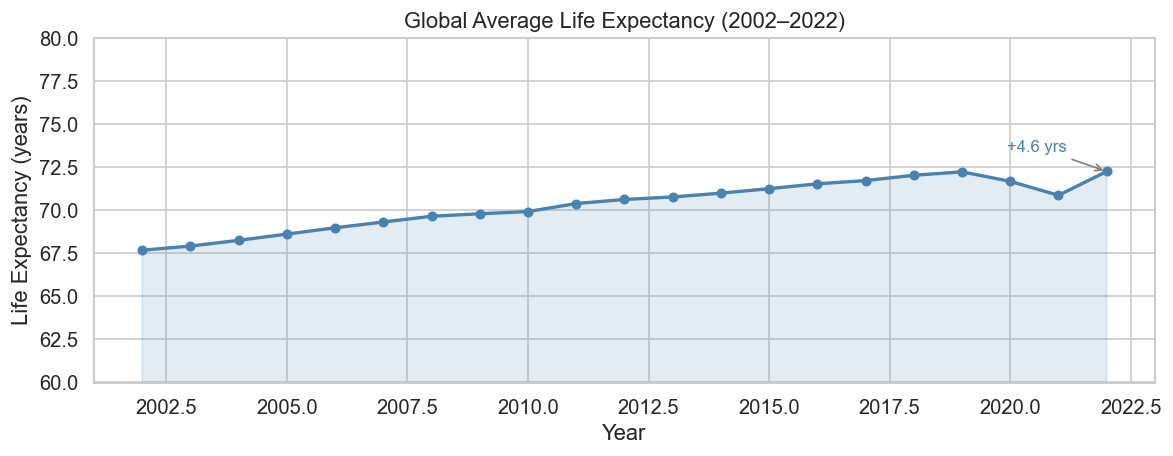

Life expectancy increased from 67.7 to 72.2 years (+4.6 yrs over 20 years)


In [12]:
le_trend = df.groupby('year')['Average Life Expectancy'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(le_trend['year'], le_trend['Average Life Expectancy'],
        marker='o', linewidth=2, color='steelblue', markersize=5)
ax.fill_between(le_trend['year'], le_trend['Average Life Expectancy'],
                alpha=0.15, color='steelblue')
ax.set(title='Global Average Life Expectancy (2002–2022)',
       xlabel='Year', ylabel='Life Expectancy (years)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
start_val = le_trend.iloc[0]['Average Life Expectancy']
end_val   = le_trend.iloc[-1]['Average Life Expectancy']
ax.annotate(f'+{end_val - start_val:.1f} yrs', xy=(2022, end_val),
            xytext=(-60, 12), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='grey'),
            fontsize=10, color='steelblue')

# Adjust the y-axis range to focus on the relevant range of life expectancy values
ax.set_ylim(60, 80)

plt.tight_layout()
plt.show()
print(f"Life expectancy increased from {start_val:.1f} to {end_val:.1f} years (+{end_val-start_val:.1f} yrs over 20 years)")

### 6.2 Life Expectancy Distribution: 2002 vs 2022

Overlapping distributions show not just that average life expectancy improved, but that the spread across countries narrowed — suggesting convergence between high- and low-income nations.

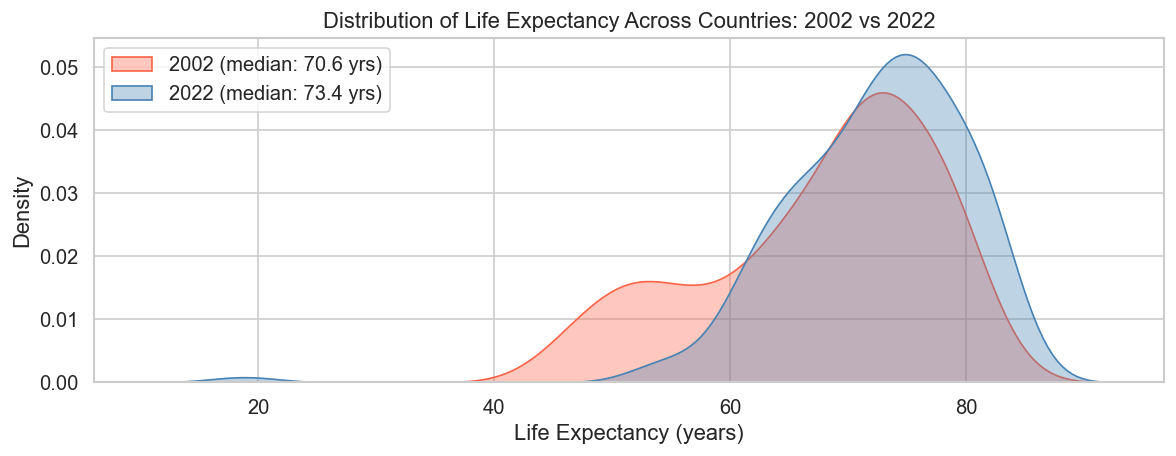

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))

for year, color, label in [(2002, 'tomato', '2002'), (2022, 'steelblue', '2022')]:
    subset = df[df['year'] == year]['Average Life Expectancy']
    sns.kdeplot(subset, ax=ax, fill=True, alpha=0.35, color=color, label=f'{label} (median: {subset.median():.1f} yrs)')

ax.set(title='Distribution of Life Expectancy Across Countries: 2002 vs 2022',
       xlabel='Life Expectancy (years)', ylabel='Density')
ax.legend()
plt.tight_layout()
plt.show()

### 6.3 Correlation Matrix

A correlation heatmap identifies pairwise linear relationships between all key numerical variables, guiding prioritisation of further analysis.

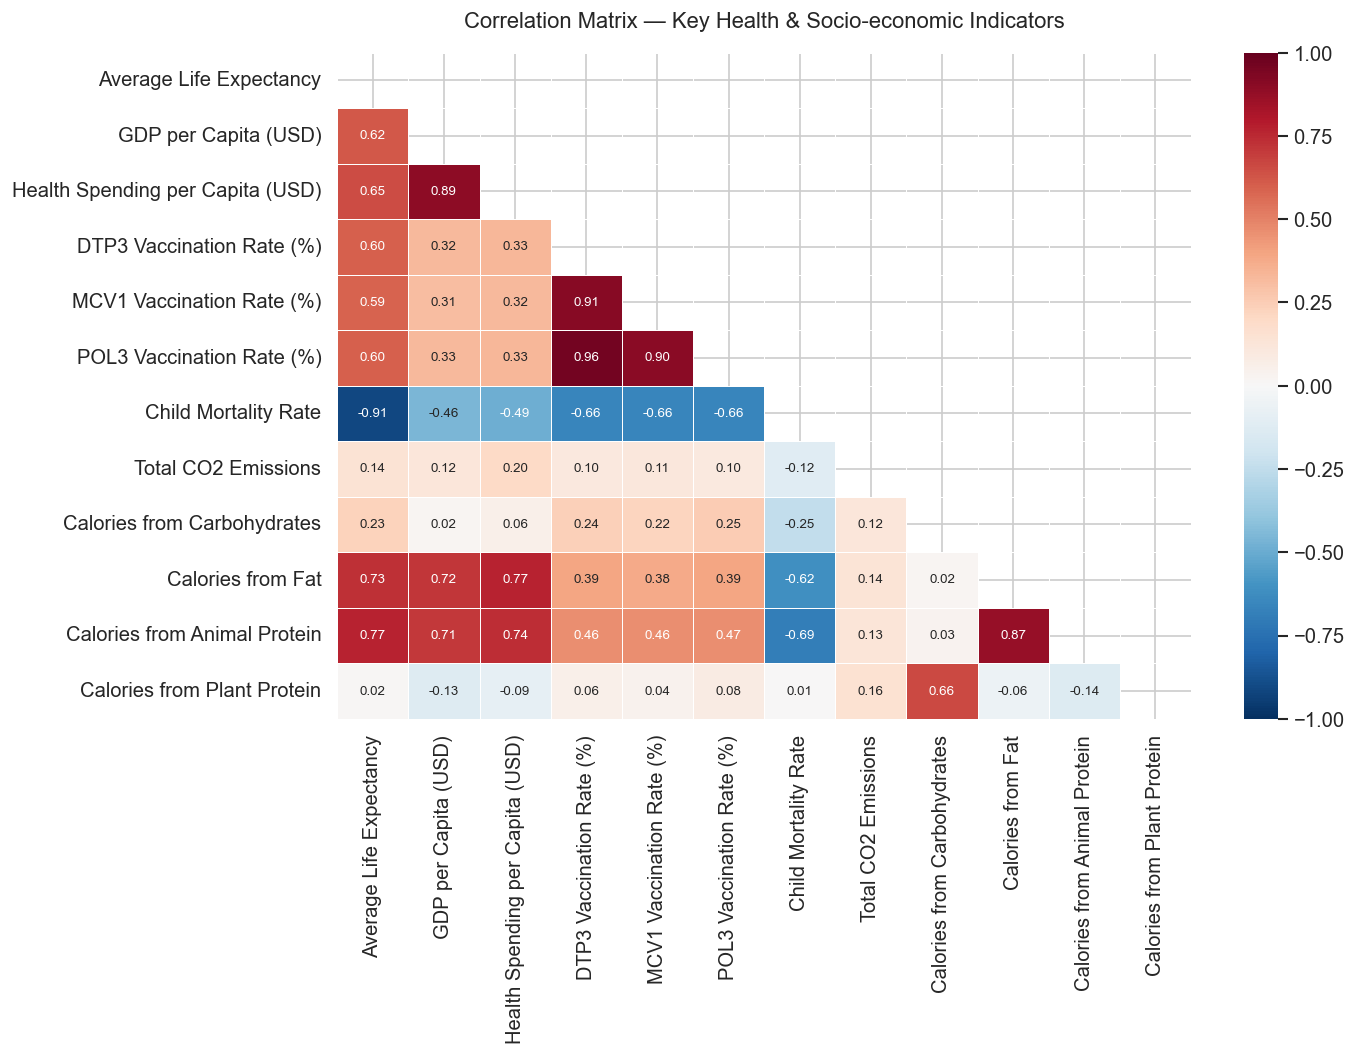

In [14]:
NUMERIC_COLS = [
    'Average Life Expectancy',
    'GDP per Capita (USD)',
    'Health Spending per Capita (USD)',
    'DTP3 Vaccination Rate (%)',
    'MCV1 Vaccination Rate (%)',
    'POL3 Vaccination Rate (%)',
    'Child Mortality Rate',
    'Total CO2 Emissions',
    'Calories from Carbohydrates',
    'Calories from Fat',
    'Calories from Animal Protein',
    'Calories from Plant Protein',
]
existing_numeric = [c for c in NUMERIC_COLS if c in df.columns]

corr = df[existing_numeric].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle mask
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Correlation Matrix — Key Health & Socio-economic Indicators', pad=15)
plt.tight_layout()
plt.show()

### 6.4 GDP per Capita vs Life Expectancy

The scatter plot illustrates the well-documented Preston Curve — a log-linear relationship between national income and life expectancy that exhibits diminishing returns at higher income levels.

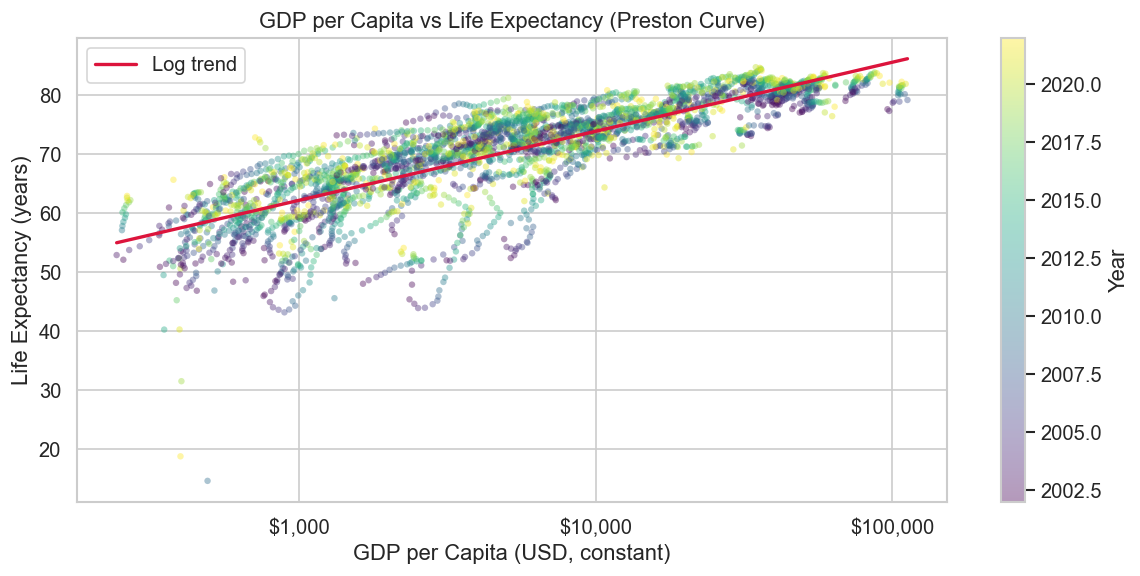

Pearson r (GDP vs Life Expectancy): 0.624


In [15]:
gdp_col = 'GDP per Capita (USD)'
le_col  = 'Average Life Expectancy'

if gdp_col in df.columns:
    plot_df = df[[gdp_col, le_col, 'year']].dropna()

    fig, ax = plt.subplots(figsize=(10, 5))
    sc = ax.scatter(plot_df[gdp_col], plot_df[le_col],
                    c=plot_df['year'], cmap='viridis', alpha=0.4, s=15, edgecolors='none')
    plt.colorbar(sc, ax=ax, label='Year')

    # Log-fit trendline
    log_gdp = np.log(plot_df[gdp_col].clip(lower=1))
    z = np.polyfit(log_gdp, plot_df[le_col], 1)
    xfit = np.linspace(plot_df[gdp_col].min(), plot_df[gdp_col].max(), 300)
    yfit = z[0] * np.log(xfit) + z[1]
    ax.plot(xfit, yfit, color='crimson', linewidth=2, label='Log trend')

    ax.set(title='GDP per Capita vs Life Expectancy (Preston Curve)',
           xlabel='GDP per Capita (USD, constant)', ylabel='Life Expectancy (years)')
    ax.set_xscale('log')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.legend()
    plt.tight_layout()
    plt.show()

    corr_val = plot_df[[gdp_col, le_col]].corr().iloc[0, 1]
    print(f"Pearson r (GDP vs Life Expectancy): {corr_val:.3f}")

### 6.5 Vaccination Rates vs Child Mortality Over Time

Average vaccination coverage (DTP3, MCV1, POL3) and child mortality are tracked by year to demonstrate their inverse relationship — a key public health finding.

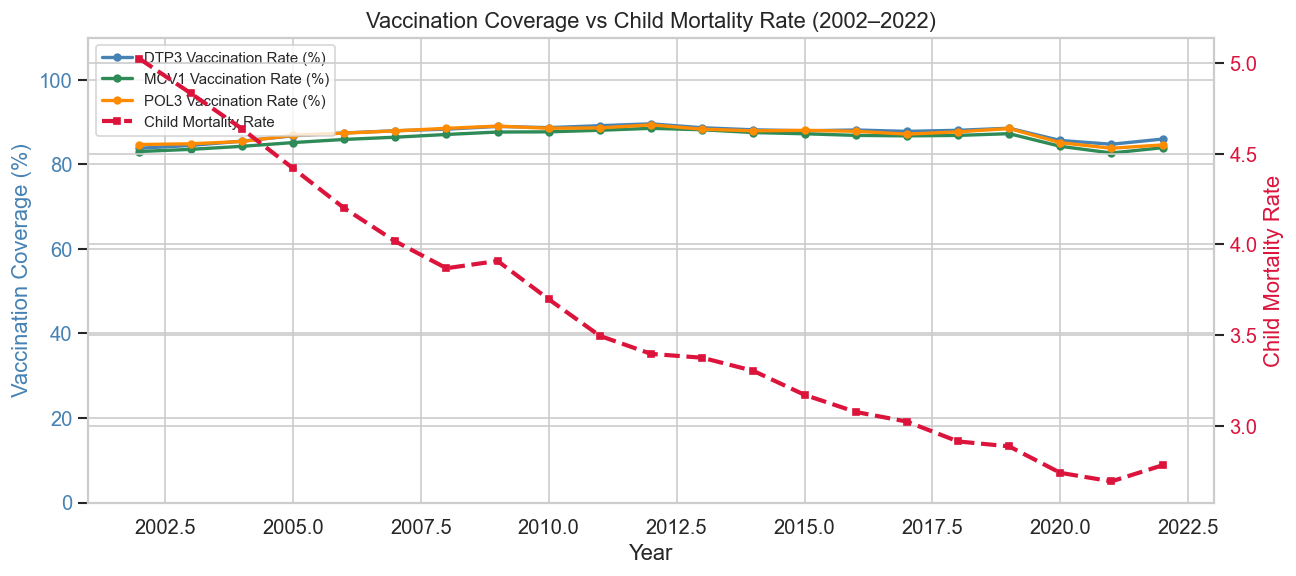

In [16]:
vax_cols = [c for c in ['DTP3 Vaccination Rate (%)', 'MCV1 Vaccination Rate (%)', 'POL3 Vaccination Rate (%)'] if c in df.columns]
cm_col   = 'Child Mortality Rate'

if vax_cols and cm_col in df.columns:
    trend = df.groupby('year')[vax_cols + [cm_col]].mean().reset_index()

    fig, ax1 = plt.subplots(figsize=(11, 5))
    colors = ['steelblue', 'seagreen', 'darkorange']
    for col, color in zip(vax_cols, colors):
        ax1.plot(trend['year'], trend[col], marker='o', markersize=4,
                 linewidth=2, color=color, label=col)

    ax1.set_ylabel('Vaccination Coverage (%)', color='steelblue')
    ax1.tick_params(axis='y', labelcolor='steelblue')
    ax1.set_ylim(0, 110)

    ax2 = ax1.twinx()
    ax2.plot(trend['year'], trend[cm_col], color='crimson', linewidth=2.5,
             linestyle='--', marker='s', markersize=4, label='Child Mortality Rate')
    ax2.set_ylabel('Child Mortality Rate', color='crimson')
    ax2.tick_params(axis='y', labelcolor='crimson')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
    ax1.set(title='Vaccination Coverage vs Child Mortality Rate (2002–2022)', xlabel='Year')
    plt.tight_layout()
    plt.show()

### 6.6 Healthcare Spending vs Life Expectancy

Points are coloured by GDP bracket to highlight that the relationship between spending and outcomes depends heavily on national income context.

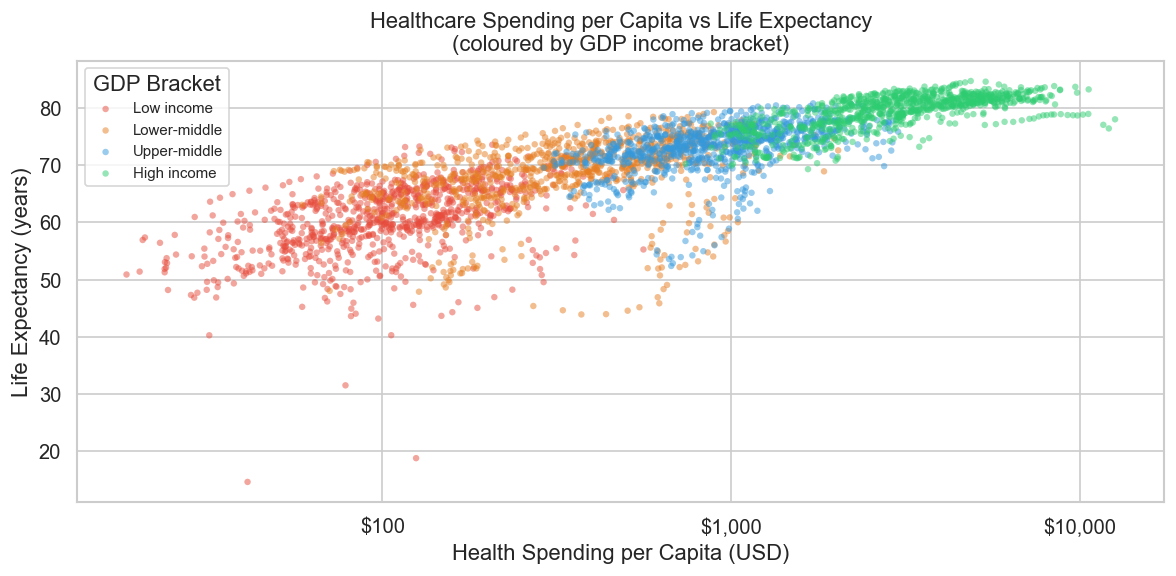

In [17]:
hs_col  = 'Health Spending per Capita (USD)'
gdp_col = 'GDP per Capita (USD)'
le_col  = 'Average Life Expectancy'

if all(c in df.columns for c in [hs_col, gdp_col, le_col]):
    plot_df = df[[hs_col, le_col, gdp_col]].dropna()

    # GDP quartile bracket labels
    plot_df = plot_df.copy()
    plot_df['GDP Bracket'] = pd.qcut(
        plot_df[gdp_col], q=4,
        labels=['Low income', 'Lower-middle', 'Upper-middle', 'High income']
    )

    fig, ax = plt.subplots(figsize=(10, 5))
    palette = {'Low income': '#e74c3c', 'Lower-middle': '#e67e22',
               'Upper-middle': '#3498db', 'High income': '#2ecc71'}
    for bracket, grp in plot_df.groupby('GDP Bracket'):
        ax.scatter(grp[hs_col], grp[le_col], alpha=0.5, s=15,
                   label=bracket, color=palette[bracket], edgecolors='none')

    ax.set(title='Healthcare Spending per Capita vs Life Expectancy\n(coloured by GDP income bracket)',
           xlabel='Health Spending per Capita (USD)', ylabel='Life Expectancy (years)')
    ax.set_xscale('log')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.legend(title='GDP Bracket', fontsize=9)
    plt.tight_layout()
    plt.show()

### 6.7 Top & Bottom 10 Countries by Life Expectancy Change (2002–2022)

Countries are ranked by absolute improvement in life expectancy over the 20-year period, highlighting which nations made the greatest strides and which stagnated or regressed.

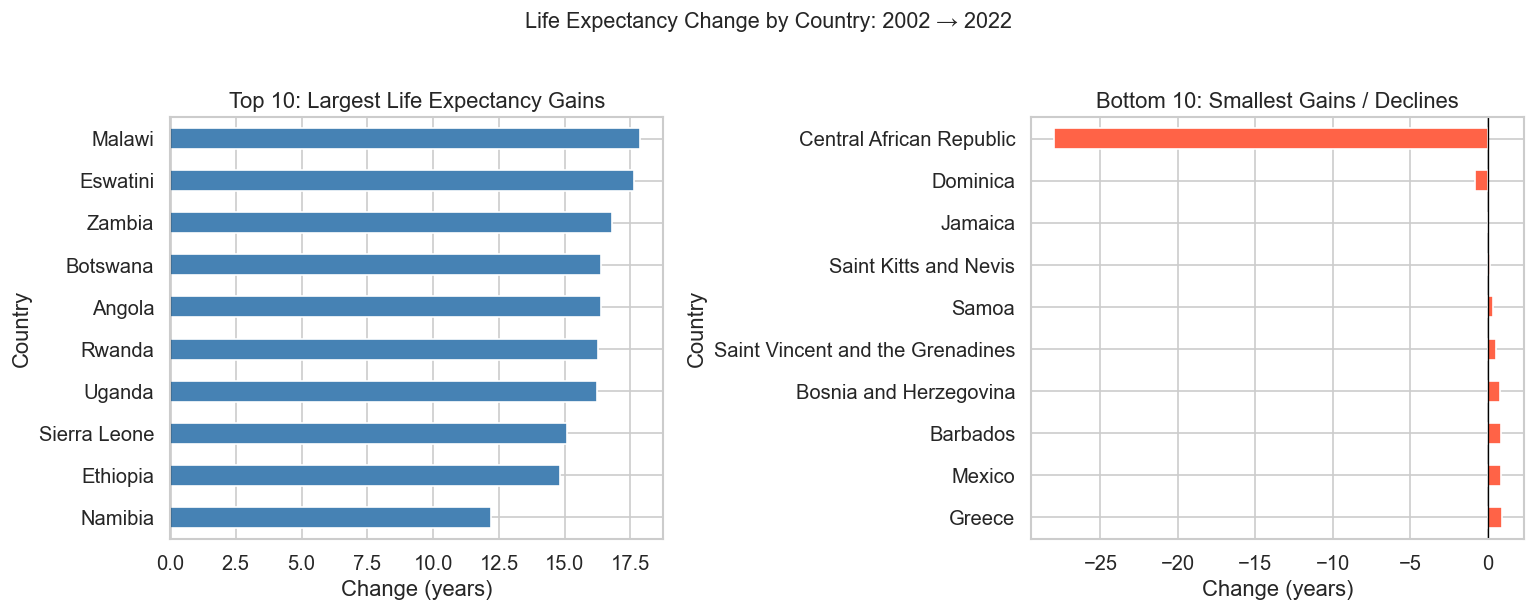

In [18]:
le_col = 'Average Life Expectancy'

le_2002 = df[df['year'] == 2002].set_index('Country')[le_col]
le_2022 = df[df['year'] == 2022].set_index('Country')[le_col]
le_change = (le_2022 - le_2002).dropna().sort_values(ascending=False)

top10    = le_change.head(10)
bottom10 = le_change.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

top10.sort_values().plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set(title='Top 10: Largest Life Expectancy Gains', xlabel='Change (years)')
axes[0].axvline(0, color='black', linewidth=0.8)

bottom10.sort_values(ascending=False).plot(kind='barh', ax=axes[1], color='tomato', edgecolor='white')
axes[1].set(title='Bottom 10: Smallest Gains / Declines', xlabel='Change (years)')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.suptitle('Life Expectancy Change by Country: 2002 → 2022', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## Section 7 — Export

The cleaned, unified dataframe is exported to Excel format for downstream visualisation in Tableau Desktop. A final shape and sample are printed as a confirmation audit.

In [19]:
OUTPUT_FILE = '../data/life_expectancy_analysis.xlsx'

df.to_excel(OUTPUT_FILE, index=False)

print(f"✓ Dataset exported to '{OUTPUT_FILE}'")
print(f"  Shape        : {df.shape}  ({df['Country'].nunique()} countries, {df['year'].nunique()} years)")
print(f"  Year range   : {df['year'].min()} – {df['year'].max()}")
print(f"  Columns      : {list(df.columns)}")
print()
df.tail(5)

✓ Dataset exported to '../data/life_expectancy_analysis.xlsx'
  Shape        : (3497, 15)  (173 countries, 21 years)
  Year range   : 2002 – 2022
  Columns      : ['Country', 'code', 'year', 'Average Life Expectancy', 'MCV1 Vaccination Rate (%)', 'DTP3 Vaccination Rate (%)', 'POL3 Vaccination Rate (%)', 'GDP per Capita (USD)', 'Health Spending per Capita (USD)', 'Calories from Animal Protein', 'Calories from Plant Protein', 'Calories from Fat', 'Calories from Carbohydrates', 'Total CO2 Emissions', 'Child Mortality Rate']



,Country,code,year,Average Life Expectancy,MCV1 Vaccination Rate (%),DTP3 Vaccination Rate (%),POL3 Vaccination Rate (%),GDP per Capita (USD),Health Spending per Capita (USD),Calories from Animal Protein,Calories from Plant Protein,Calories from Fat,Calories from Carbohydrates,Total CO2 Emissions,Child Mortality Rate
4032,Zimbabwe,ZWE,2014,58.1060,92.0,91.0,92.0,1381.2540,203.30057,105.519950,115.679950,591.0297,1260.5393,11946148.0,6.18
4033,Zimbabwe,ZWE,2015,58.9895,86.0,87.0,88.0,1387.1263,191.68187,111.120020,114.280014,604.5300,1245.5802,12016794.0,5.98
4034,Zimbabwe,ZWE,2016,59.7601,95.0,90.0,90.0,1378.3425,188.83382,111.039950,119.239944,618.6597,1291.8094,10588242.0,5.69
4035,Zimbabwe,ZWE,2017,60.2626,90.0,89.0,89.0,1422.9194,143.32605,106.079980,125.079970,589.5899,1360.1199,9830570.0,5.50
4036,Zimbabwe,ZWE,2018,60.9055,88.0,89.0,89.0,1472.1460,114.42487,103.399956,127.039940,608.3997,1366.1095,11209238.0,5.23


---
## Section 8 — Summary of Findings

| Finding | Observation |
|---|---|
| **Life expectancy trend** | Global average rose by ~4 years from 2002 to 2022, with narrowing cross-country dispersion |
| **GDP & life expectancy** | Strong positive log-linear relationship (Preston Curve); diminishing returns above ~$20,000 GDP/capita |
| **Vaccination** | DTP3, MCV1, POL3 coverage rose consistently; inversely correlated with child mortality |
| **Healthcare spending** | Positive association with life expectancy, but high variability at similar spending levels — efficiency matters more than expenditure alone |
| **CO₂ emissions** | Linked to economic development but no direct short-term association with life expectancy |
| **Diet** | Macro-nutrient composition stable; total calorie intake rising over time |

### Limitations
- Country-level averages may mask sub-national inequalities
- Inner merge strategy biases towards countries with strong data reporting infrastructure
- Correlation analysis does not establish causation
- Dietary data are highly aggregated and may not capture meaningful nutritional variation

### Next Steps
- Apply regression modelling (OLS, fixed effects) to quantify variable contributions
- Incorporate sub-national health indicators for within-country analysis
- Extend the pipeline to auto-refresh when OWID updates source datasets

---
## References

1. Our World in Data (2024). *Our World in Data*. https://ourworldindata.org
2. World Bank (2024). *World Development Indicators*. https://databank.worldbank.org
3. WHO/UNICEF (2024). *WUENIC Immunization Coverage Estimates*. https://www.who.int/data/gho/data/themes/immunization
4. Global Carbon Project (2024). *Global Carbon Budget*. https://globalcarbonbudget.org
5. FAO (2024). *FAOSTAT Food Balance Sheets*. https://www.fao.org/faostat
6. Gapminder (2023). *Child mortality estimates*. https://www.gapminder.org/data/